In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from numpy.polynomial.polynomial import Polynomial
import numpy as np
import ast


In [47]:
df_results_6_nodes_just_positive = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_6_nodes_2025-07-17.csv")

Group: (1,)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10
Polynomial Coefficients: [1.30698157e+00 2.06227072e-16 3.67307360e-01]
Y-intercept at x = 0: 1.3069815746713878
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.020581146177624614


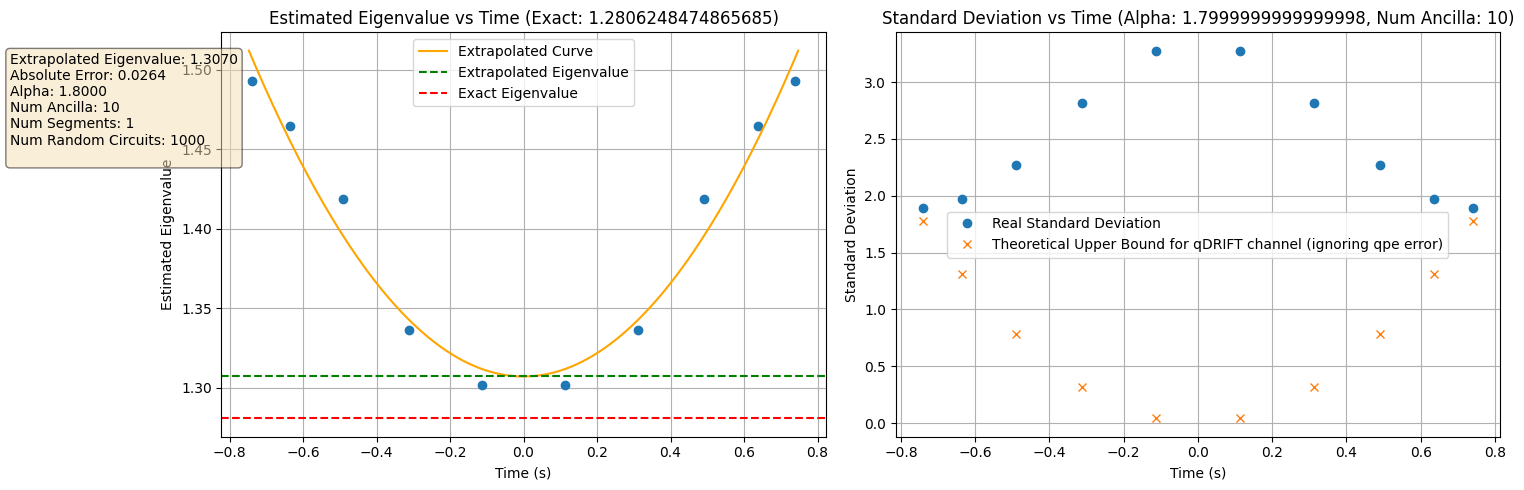

Group: (2,)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10
Polynomial Coefficients: [ 1.29391368e+00  3.17933403e-16 -3.29658911e-02]
Y-intercept at x = 0: 1.2939136819263728
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.010376836327895557


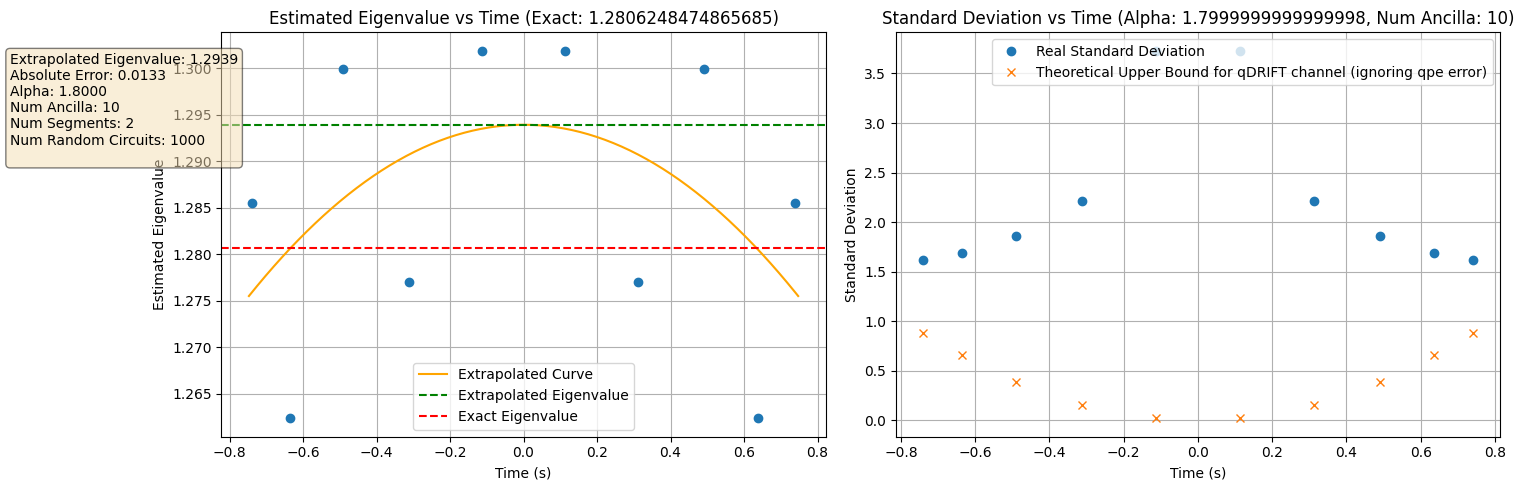

Group: (10,)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 10
Polynomial Coefficients: [ 1.29192530e+00  2.62080238e-16 -2.33284136e-02]
Y-intercept at x = 0: 1.2919253006270255
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.008824171389955438


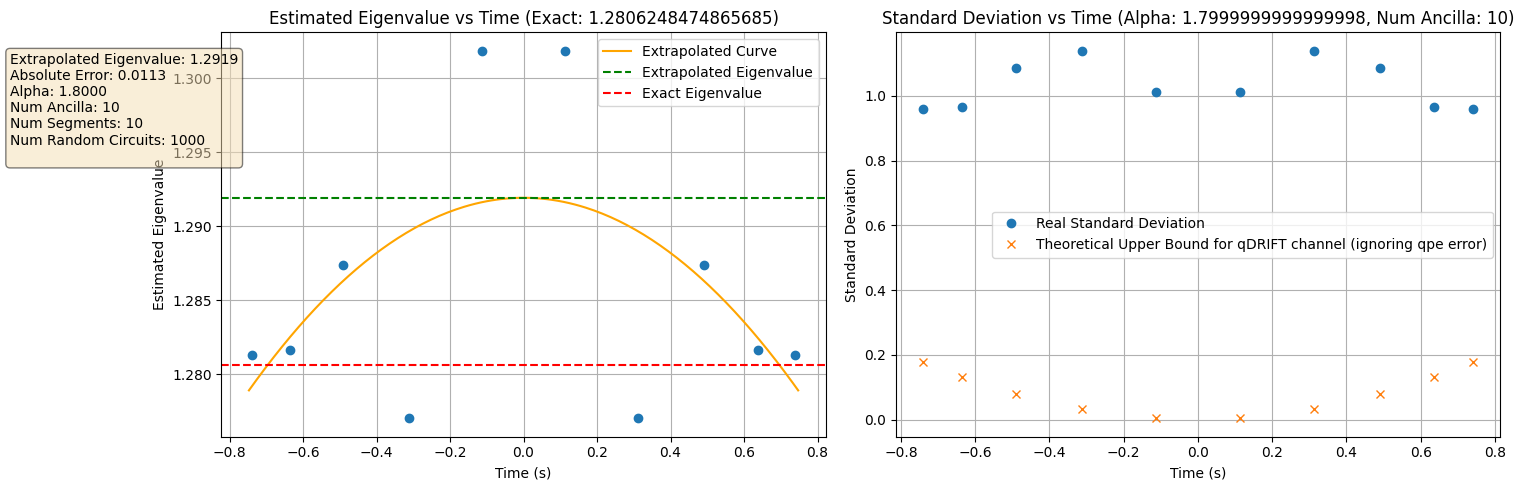

In [50]:


def plot_cheby_extrapolation(groupbys, df, show_stdevs):
    for group_name, group in df.groupby(groupbys):
        print(f"Group: {group_name}")
        exact_eigenvalue = ast.literal_eval(group["Exact Eigenvalue"].iloc[0]).real
        print(f"Exact Eigenvalue: {exact_eigenvalue}")
        alpha = group["Alpha"].iloc[0]
        print(f"Alpha: {alpha}")
        num_ancilla = group["Num Ancilla"].iloc[0]
        print(f"Num Ancilla: {num_ancilla}")
        num_qdrift_segments = group["num segments per invocation"].iloc[0] if "num segments per invocation" in group.columns else 1

        # mirror the results across the y-axis to duplicte the data (phyics math moment)
        df_mirror = group.copy()
        df_mirror["Time"] = -df_mirror["Time"]
        group = pd.concat([group, df_mirror])

        # Calculate theoretical upper bound for standard deviation
        stdev_theoretical_upper_bound = (alpha ** 2 * group["Time"] ** 2) / num_qdrift_segments

        # if show_stdevs is True, plot two subplots, one for the estimated eigenvalue and one for the standard deviation
        if show_stdevs:
            fig, axs = plt.subplots(1, 2, figsize=(15, 5))
            ax1, ax2 = axs
        else:
            fig, ax1 = plt.subplots(figsize=(10, 6))
            ax2 = None
        ax1.plot(group["Time"], group["Estimated Eigenvalue"], marker='o', linestyle='None')
        # fit a polynomial to the data
        coeffs = Polynomial.fit(group["Time"], group["Estimated Eigenvalue"], 2).convert().coef
        print(f"Polynomial Coefficients: {coeffs}")
        y_intercept = coeffs[0]
        print(f"Y-intercept at x = 0: {y_intercept}")
        print(f"Correct eigenvalue: {exact_eigenvalue}")
        print(f"Error ratio: {abs(exact_eigenvalue - y_intercept) / exact_eigenvalue}")
        # Extrapolation range (extend 20% beyond the last x)
        x_extra = np.linspace(group["Time"].min() * 1.01, group["Time"].max() * 1.01, 200)
        y_extra = sum(c * x_extra**i for i, c in enumerate(coeffs))
        ax1.plot(x_extra, y_extra, label='Extrapolated Curve', color='orange')
        ax1.axhline(y=y_intercept, color='g', linestyle='--',
                    label='Extrapolated Eigenvalue')
        ax1.axhline(y=exact_eigenvalue, color='r', linestyle='--',
                    label='Exact Eigenvalue')   
        ax1.set_xlabel("Time (s)")
        ax1.set_ylabel("Estimated Eigenvalue")
        ax1.set_title(f"Estimated Eigenvalue vs Time (Exact: {exact_eigenvalue})")
        # add textbox info about the extrapolated eigenvalue
        stats_text = (f"Extrapolated Eigenvalue: {y_intercept:.4f}\n"
                        f"Absolute Error: {abs(exact_eigenvalue - y_intercept):.4f}\n"
                        f"Alpha: {alpha:.4f}\n"
                        f"Num Ancilla: {num_ancilla}\n"
                        f"Num Segments: {num_qdrift_segments}\n")
        if "Num Random Circuits" in group.columns:
            num_random_circuits = group["Num Random Circuits"].iloc[0]
            stats_text += f"Num Random Circuits: {num_random_circuits}\n"
        ax1.text(-0.35, 0.95, stats_text, transform=ax1.transAxes,
                 fontsize=10, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        # plot the theoretical upper bound for standard deviation and real stdev vs time
        if show_stdevs:
            ax2.plot(group["Time"], group["stdev energy"], marker='o', linestyle='None', label='Real Standard Deviation')
            ax2.plot(group["Time"], stdev_theoretical_upper_bound, marker='x', linestyle='None', label='Theoretical Upper Bound for qDRIFT channel (ignoring qpe error)')
            ax2.set_xlabel("Time (s)")
            ax2.set_ylabel("Standard Deviation")
            ax2.set_title(f"Standard Deviation vs Time (Alpha: {alpha}, Num Ancilla: {num_ancilla})")
            ax2.grid(True)
            ax2.legend()
        ax1.grid(True)
        ax1.legend()
        plt.tight_layout()
        plt.show()


# removethe row with the biggest time value
df_results_6_nodes_just_positive = df_results_6_nodes_just_positive[df_results_6_nodes_just_positive["Time"] < max(df_results_6_nodes_just_positive["Time"])] 
plot_cheby_extrapolation(["num segments per invocation"], df_results_6_nodes_just_positive, show_stdevs=True)

Group: (np.int64(1), np.int64(11), np.int64(1))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [ 1.10685062e+00 -3.49679343e-17  8.31285433e-02]
Y-intercept at x = 0: 1.1068506206493463
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.13569487362226493


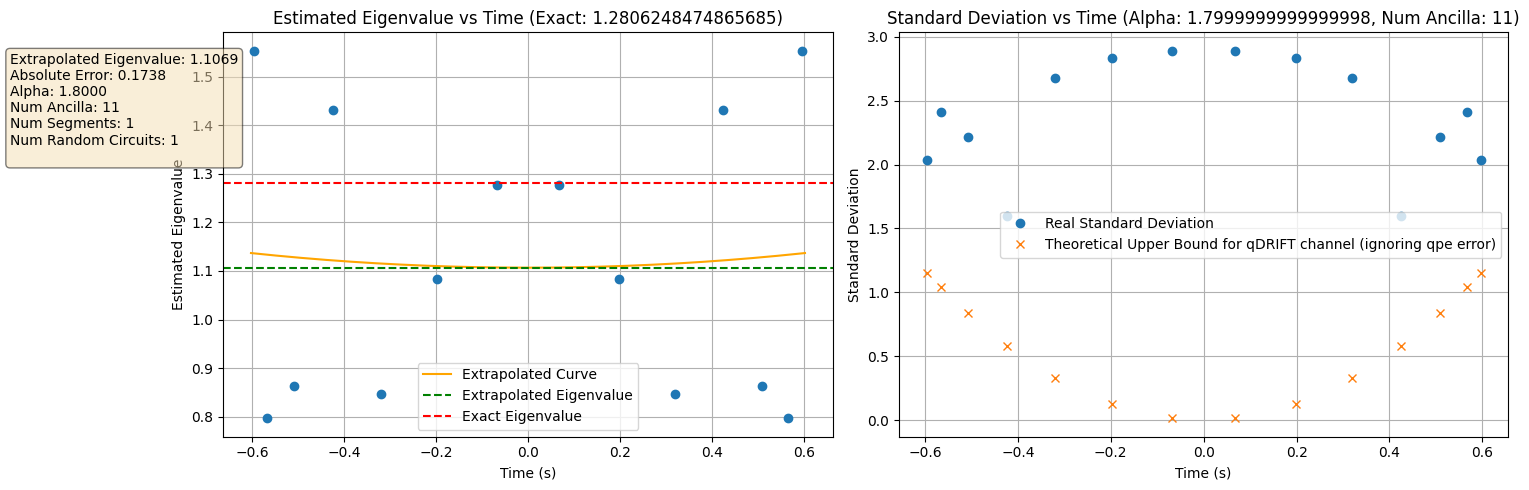

Group: (np.int64(1), np.int64(11), np.int64(2000))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [1.27898864e+00 1.04903803e-16 5.23829642e-01]
Y-intercept at x = 0: 1.2789886410672282
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.0012776625586732723


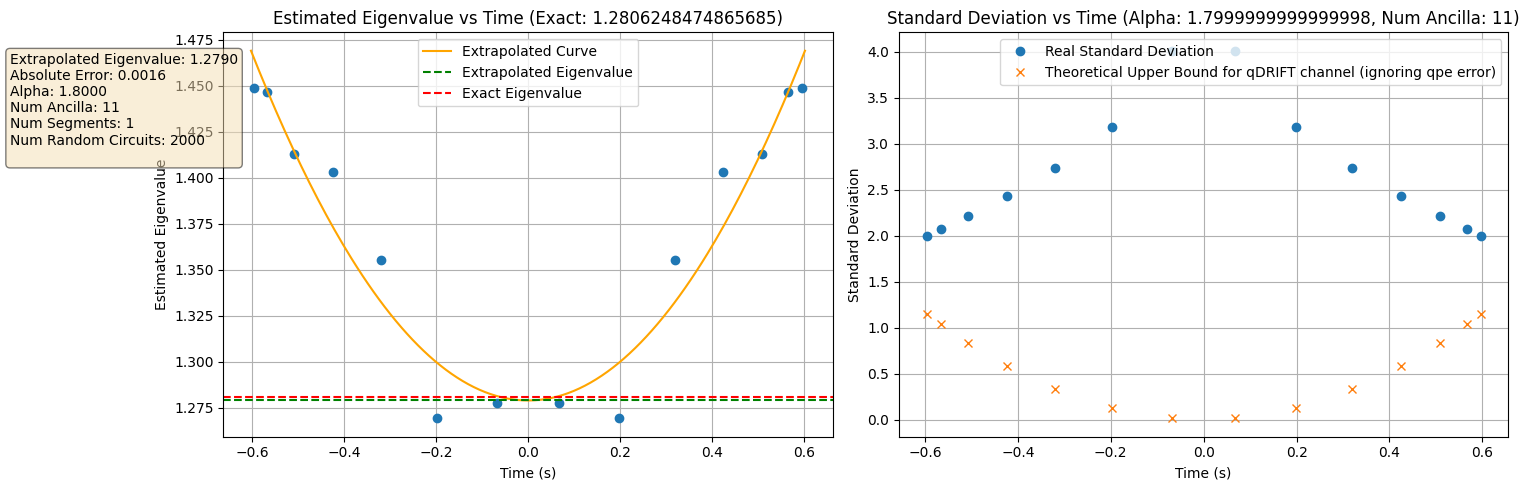

Group: (np.int64(1), np.int64(12), np.int64(1))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 12
Polynomial Coefficients: [1.21976969e+00 6.99358686e-17 2.82207678e-01]
Y-intercept at x = 0: 1.219769693478518
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.04751989165873863


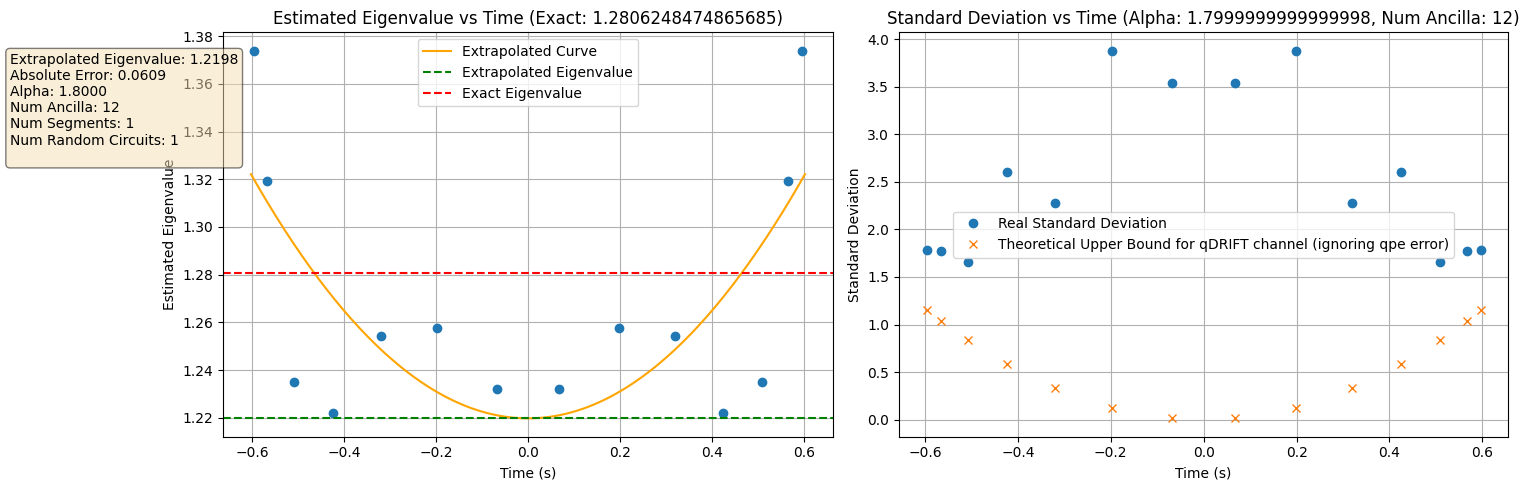

Group: (np.int64(1), np.int64(12), np.int64(2000))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 12
Polynomial Coefficients: [1.29233056e+00 6.99358686e-17 4.97016112e-01]
Y-intercept at x = 0: 1.2923305600802772
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.009140625856731673


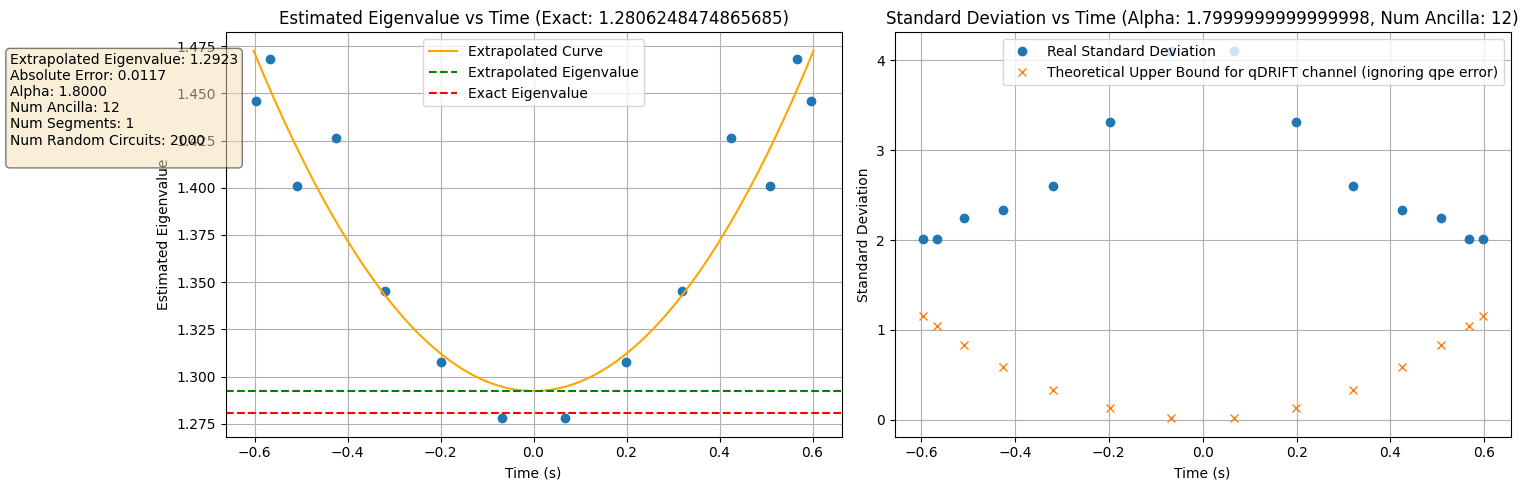

In [53]:
df_6_nodes_many_crcs = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_6_nodes_2025-07-23.csv")
plot_cheby_extrapolation(["num segments per invocation", "Num Ancilla", "Num Random Circuits"], df_6_nodes_many_crcs, show_stdevs=True)

Group: (np.int64(1), np.int64(11), np.int64(1))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [1.28439160e+00 3.92509607e-16 1.55405184e+00]
Y-intercept at x = 0: 1.2843916020375357
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.0029413411416778766


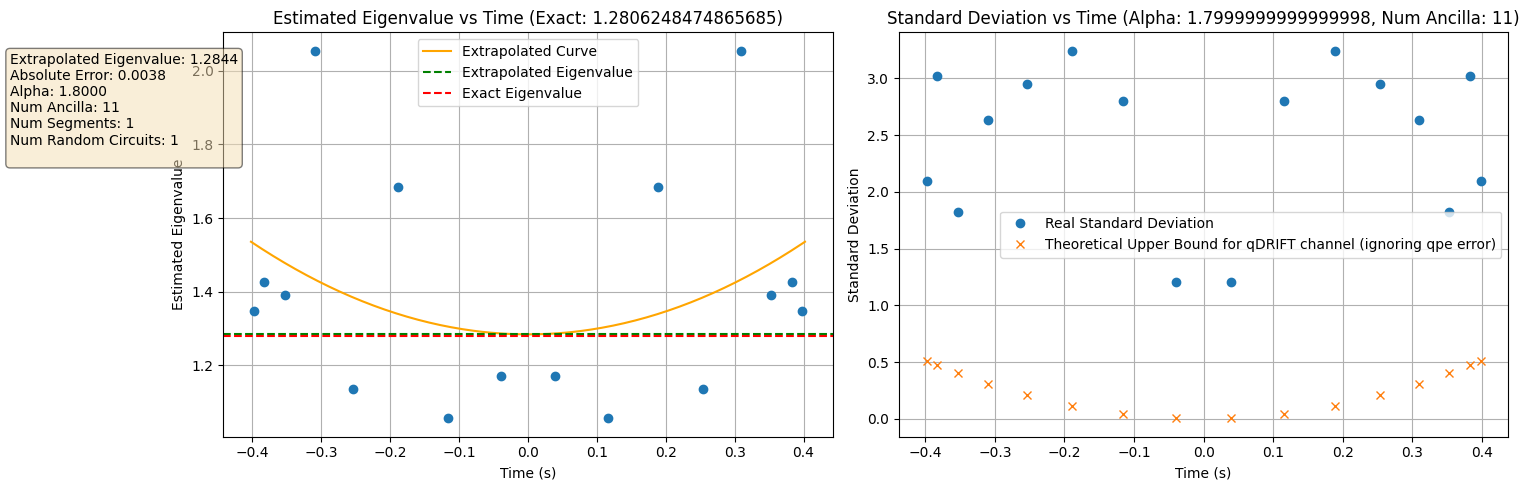

Group: (np.int64(1), np.int64(11), np.int64(1000))
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [1.27574496e+00 2.69850355e-16 5.90020647e-01]
Y-intercept at x = 0: 1.2757449649784238
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.0038105480443567773


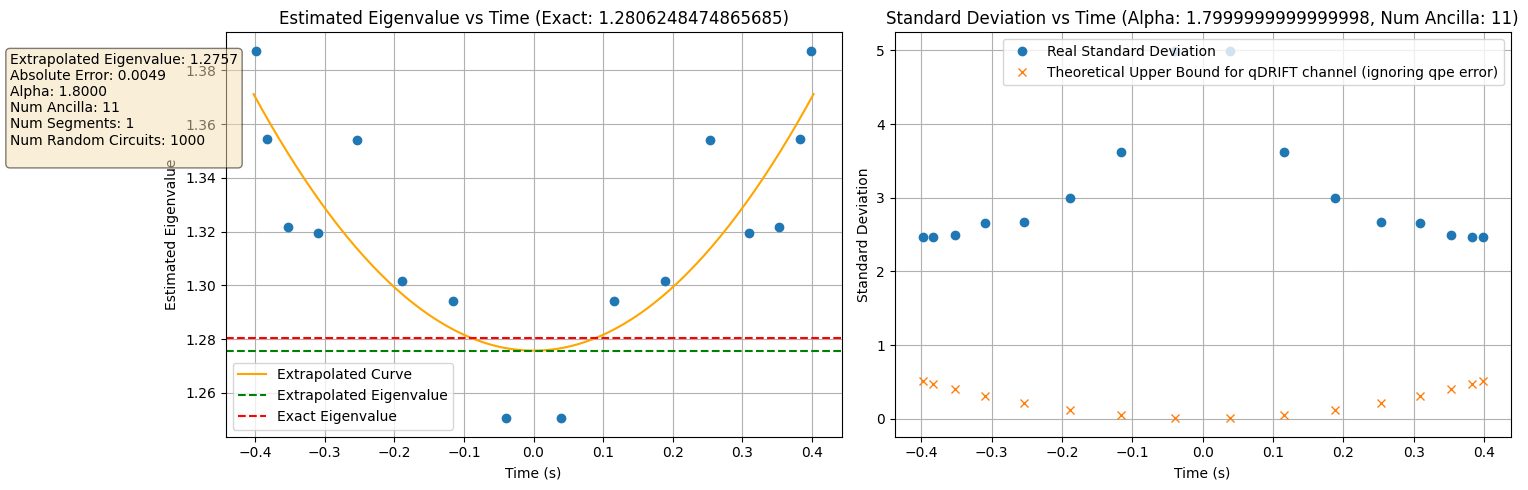

In [40]:
df_8_nodes_just_positive = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_8_nodes_2025-07-23.csv")
plot_cheby_extrapolation(["num segments per invocation", "Num Ancilla", "Num Random Circuits"], df_8_nodes_just_positive, show_stdevs=True)

In [30]:
df_5_nodes_just_positive = pd.read_csv(r"C:\Users\Ro\Desktop\qDriftExtraPolation\qdrift_ising_model_5_nodes_2025-07-10.csv")
df_5_nodes_just_positive

,Num Qubits,Time,Shots,Num Ancilla,Exact Eigenvalue,Expected Phase,Most Probable Bitstring,Estimated Phase,Estimated Eigenvalue,Eigenvalue Error,...,type of Hamiltonian,Num Random Circuits,Num Shots per Circuit,Circuit Depth,Raw results,estimnated energies counts,max energy,min energy,stdev energy,mean energy
0,2,0.574472,100,11,(1.2806248474865685+0j),0.117088,100001011,0.131836,1.441932,0.161307,...,Ising,100,1,2050,"{'00110100101': 1, '11100001111': 1, '00010000...","{np.float64(2.2483451332016036): 1, np.float64...",5.441957,-4.672926,2.023595,1.036375
1,2,0.716075,100,11,(1.2806248474865685+0j),0.145949,100100011,0.184082,1.615224,0.334599,...,Ising,100,1,2050,"{'00100100011': 2, '00110110111': 1, '01001001...","{np.float64(1.246764360010587): 2, np.float64(...",4.254423,-4.314405,1.591541,1.287381
2,2,0.790520,100,11,(1.2806248474865685+0j),0.161122,110100000,0.187500,1.490281,0.209657,...,Ising,100,1,2050,"{'00100010011': 1, '01001100010': 1, '00111011...","{np.float64(1.0672587785024836): 1, np.float64...",3.613156,-3.974084,1.591499,1.165136
3,2,0.790520,100,11,(2.561249694973137+0j),0.322244,1110111100,0.460205,3.657787,1.096537,...,Ising,100,1,2050,"{'01110011110': 2, '01110111011': 3, '01110111...","{np.float64(3.5937513777938177): 2, np.float64...",3.962441,-3.954679,2.592018,2.431798
4,2,0.379573,100,11,(2.561249694973137+0j),0.154727,1000011,0.190918,3.160325,0.599075,...,Ising,100,1,2050,"{'00100111100': 1, '01100100001': 1, '00101100...","{np.float64(2.5541244055956036): 1, np.float64...",7.840192,-8.195830,4.038020,2.060596
5,2,0.716075,100,11,(2.561249694973137+0j),0.291898,1110001010,0.382080,3.352554,0.791304,...,Ising,100,1,2050,"{'00011000111': 1, '10001100000': 1, '01011111...","{np.float64(0.8525983080484771): 1, np.float64...",4.357249,-4.271560,2.962349,1.813035
6,2,0.379573,100,11,(1.2806248474865685+0j),0.077364,11000110,0.075195,1.244732,0.035893,...,Ising,100,1,2050,"{'00001000011': 1, '11100010100': 1, '01101110...","{np.float64(0.5415390353636248): 1, np.float64...",7.128917,-8.220078,2.850282,0.888447
7,2,0.574472,100,11,(2.561249694973137+0j),0.234175,1010011000,0.320557,3.506030,0.944780,...,Ising,100,1,2050,"{'01010011000': 2, '01100110101': 1, '00011100...","{np.float64(3.546083535500867): 2, np.float64(...",5.441957,-5.415254,3.210538,2.034245
8,2,0.150455,100,11,(2.561249694973137+0j),0.061331,10001100,0.067139,2.803802,0.242552,...,Ising,100,1,2050,"{'00010110111': 1, '00010100111': 1, '00001110...","{np.float64(3.7316054106920156): 1, np.float64...",19.534852,-17.985115,5.730312,1.536076
9,2,0.150455,100,11,(1.2806248474865685+0j),0.030665,1000001,0.031250,1.305042,0.024417,...,Ising,100,1,2050,"{'11110101110': 1, '01111000000': 1, '11111101...","{np.float64(-1.6720854845723783): 1, np.float6...",19.636809,-13.295119,4.468328,1.941658


Group: ('(1.2806248474865685+0j)',)
Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11
Polynomial Coefficients: [1.25648166e+00 1.22812895e-16 4.98528262e-01]
Y-intercept at x = 0: 1.2564816554726428
Correct eigenvalue: 1.2806248474865685
Error ratio: 0.018852665604068636


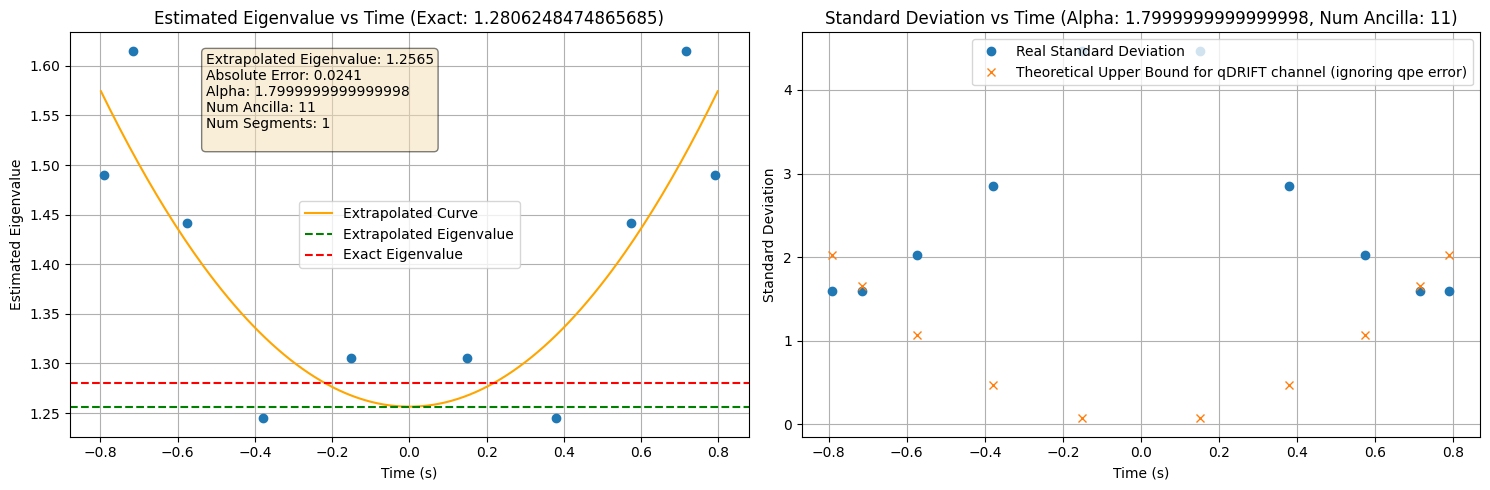

Group: ('(2.561249694973137+0j)',)
Exact Eigenvalue: 2.561249694973137
Alpha: 3.6
Num Ancilla: 11
Polynomial Coefficients: [ 2.91130923e+00 -4.91251580e-16  1.17714912e+00]
Y-intercept at x = 0: 2.9113092329367247
Correct eigenvalue: 2.561249694973137
Error ratio: 0.13667528732190218


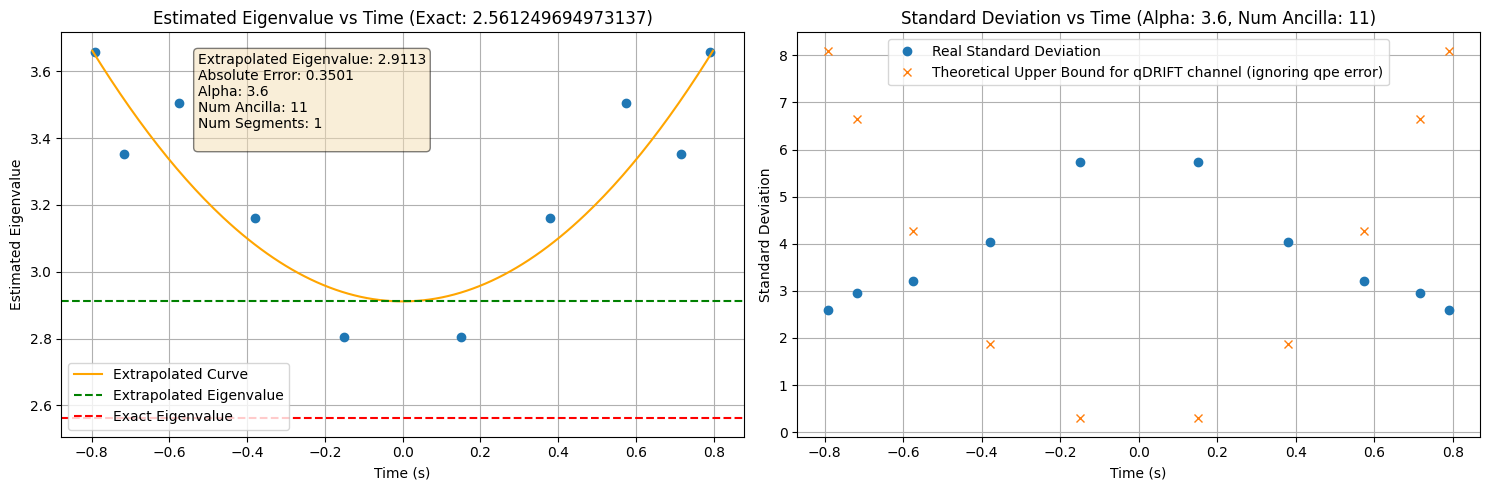

In [31]:
plot_cheby_extrapolation(["Exact Eigenvalue"], df_5_nodes_just_positive, show_stdevs=True)

Exact Eigenvalue: 1.2806248474865685
Alpha: 1.7999999999999998
Num Ancilla: 11


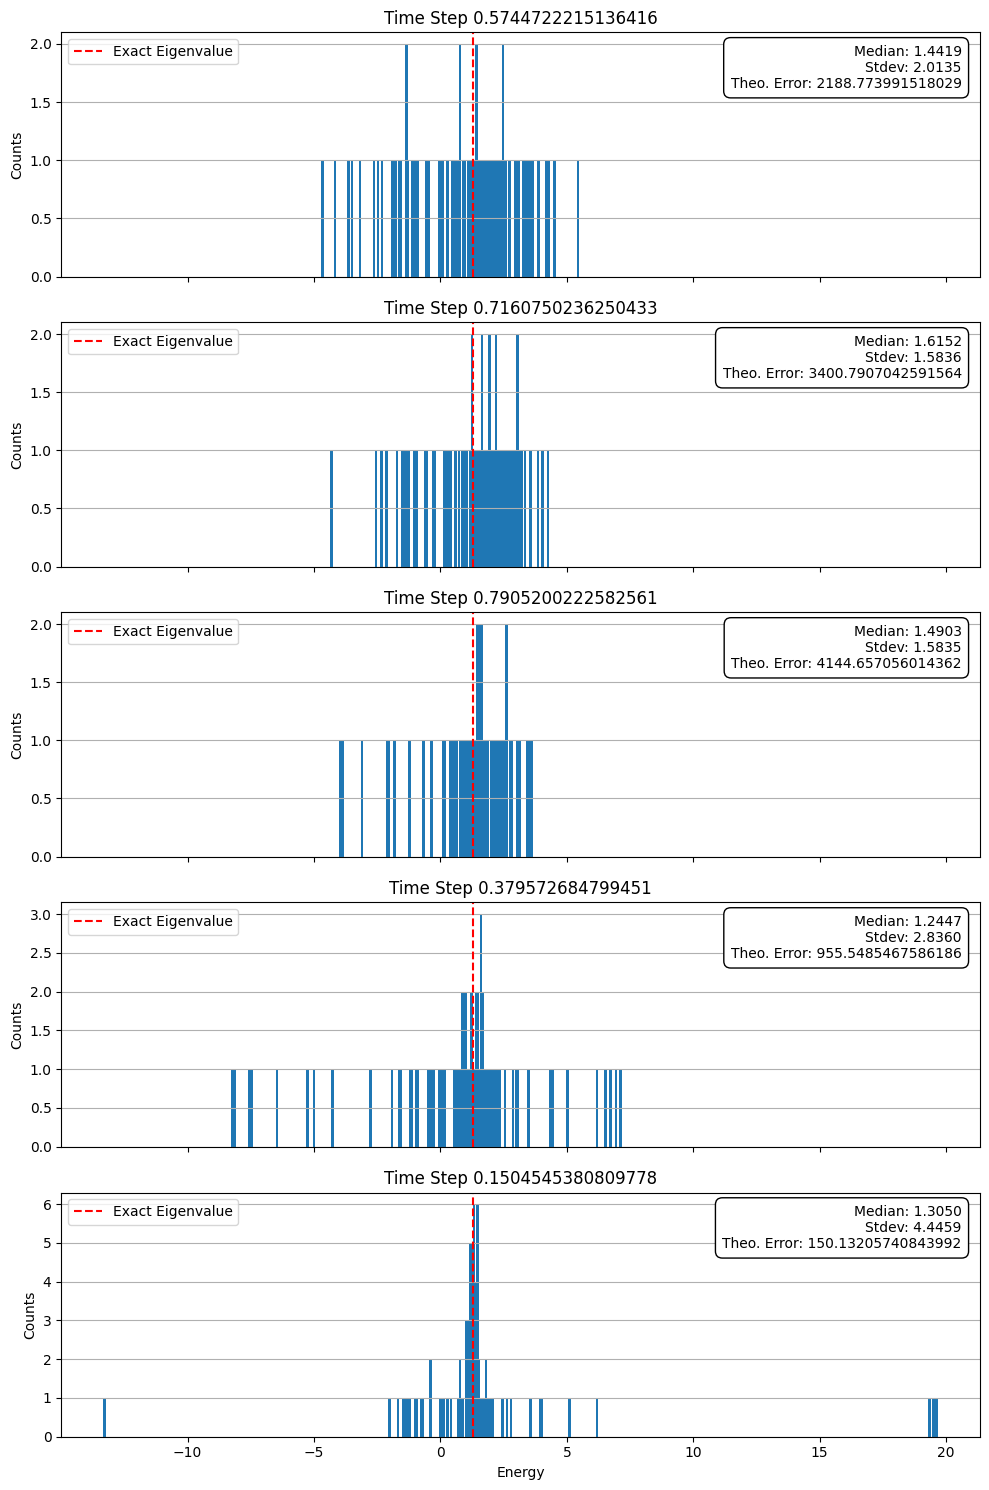

Exact Eigenvalue: 2.561249694973137
Alpha: 3.6
Num Ancilla: 11


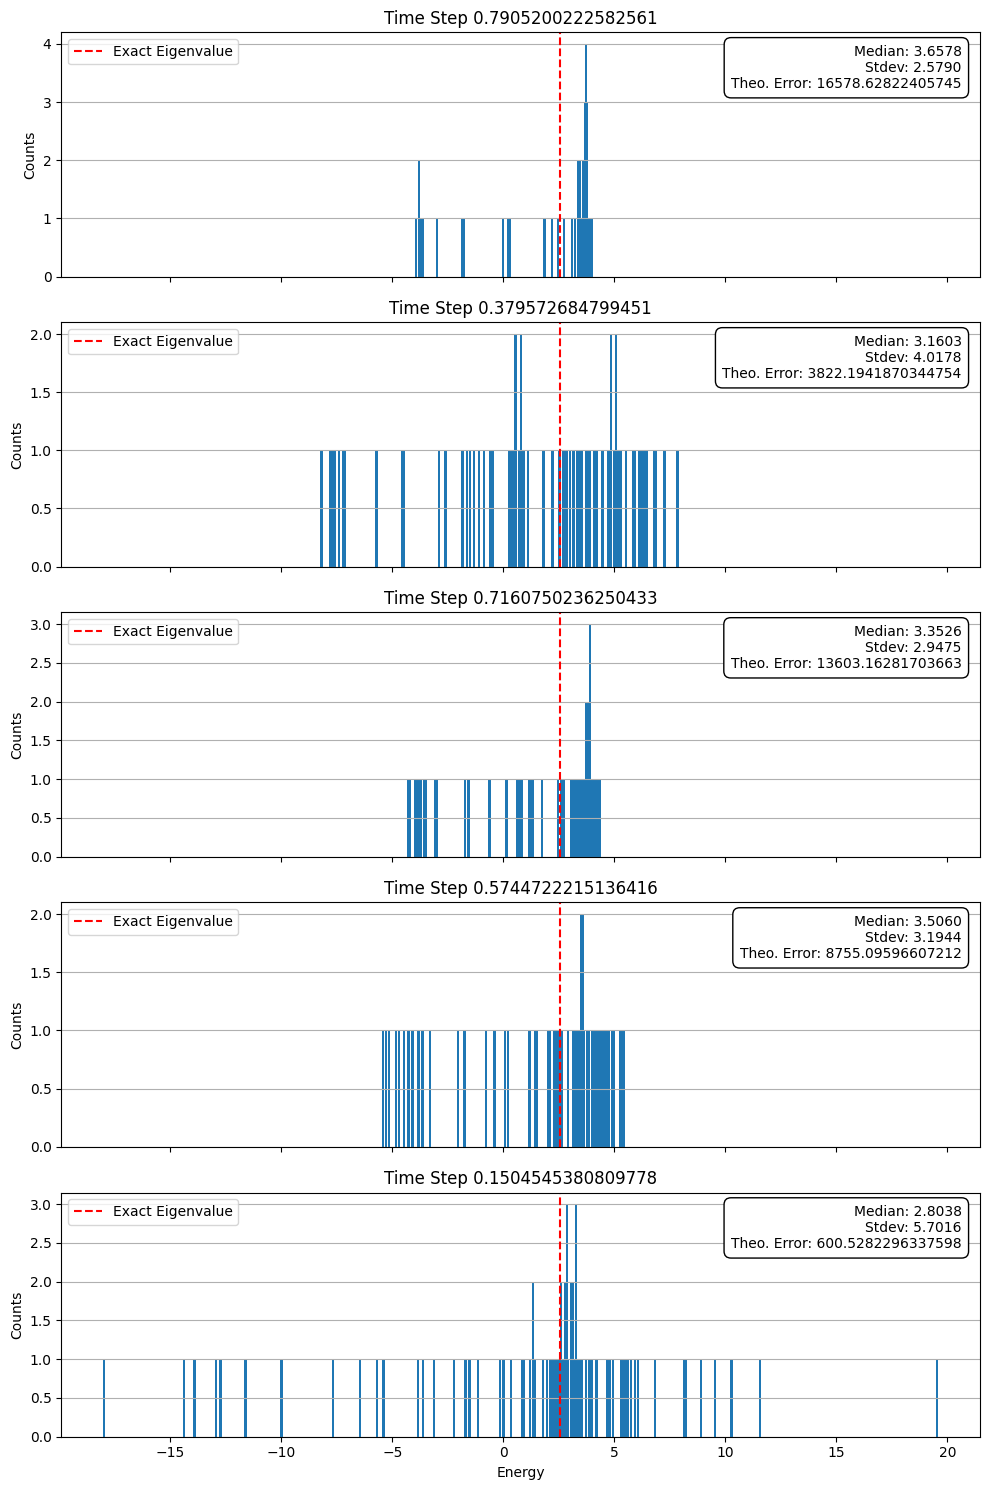

: 

In [ ]:

def plot_energy_histograms(group, exact_eigenvalue, theoretical_error, energy_counts_column="estimnated energies counts", time_column="Time"):
    """
    Plots histograms of estimated energy counts over time steps, with a text box showing
    median, standard deviation, and theoretical error.

    Parameters:
    - group: DataFrame containing energy counts and time values.
    - exact_eigenvalue: Float, value of the exact eigenvalue to mark.
    - theoretical_error: Float or list of floats for theoretical error(s) per time step.
    - energy_counts_column: Name of the column containing energy counts dictionaries.
    - time_column: Name of the column containing time step identifiers.
    """
    all_counts = group[energy_counts_column].values

    # Clean and parse
    c_cleaned = [x.replace("np.float64(", "").replace(")", "") for x in all_counts]
    counts = [ast.literal_eval(x) for x in c_cleaned]
    time_vals = group[time_column].values

    # Collect all possible energies
    all_estimated_energies = sorted(set(energy for count in counts for energy in count.keys()))

    num_times = len(counts)
    fig, axes = plt.subplots(num_times, 1, figsize=(10, 3 * num_times), sharex=True)

    if num_times == 1:
        axes = [axes]  # Ensure iterable

    # Handle theoretical_error as scalar or list
    if np.isscalar(theoretical_error):
        theoretical_error = [theoretical_error] * num_times

    for idx, (ax, count, time_val, theo_err) in enumerate(zip(axes, counts, time_vals, theoretical_error)):
        counts_for_energies = [count.get(energy, 0) for energy in all_estimated_energies]
        ax.bar(all_estimated_energies, counts_for_energies, width=0.1)
        ax.set_title(f"Time Step {time_val}")
        ax.set_ylabel("Counts")
        ax.grid(True, axis='y')
        ax.axvline(x=exact_eigenvalue, color='r', linestyle='--', label='Exact Eigenvalue')
        ax.legend()

        # Weighted statistics
        energies = np.array(all_estimated_energies)
        counts_array = np.array(counts_for_energies)
        flatten_counts = np.repeat(energies, counts_array.astype(int))
        if counts_array.sum() > 0:
            median = np.median(flatten_counts)
            stdev = np.std(flatten_counts)
            
        else:
            median = np.nan
            stdev = np.nan

        # Add text box
        stats_text = (f"Median: {median:.4f}\n"
                      f"Stdev: {stdev:.4f}\n"
                      f"Theo. Error: {theo_err}")
        ax.text(0.98, 0.95, stats_text, ha='right', va='top', transform=ax.transAxes,
                bbox=dict(facecolor='white', edgecolor='black', boxstyle='round,pad=0.5'))

    axes[-1].set_xlabel("Energy")

    plt.tight_layout()
    plt.show()

for group_name, group in df_5_nodes_just_positive.groupby("Exact Eigenvalue"):
    exact_eigenvalue = ast.literal_eval(group_name).real
    print(f"Exact Eigenvalue: {exact_eigenvalue}")
    alpha = group["Alpha"].iloc[0]
    print(f"Alpha: {alpha}")
    num_ancilla = group["Num Ancilla"].iloc[0]
    print(f"Num Ancilla: {num_ancilla}")

    stdevs = group["stdev energy"]
    stdev_theoretical_upper_bound = (alpha ** 2 * group["Time"] ** 2) * (2 ** (num_ancilla) - 1)

    plot_energy_histograms(group, exact_eigenvalue, stdev_theoretical_upper_bound)